In [87]:
import pandas as pd
from seismostats import Catalog
import matplotlib.pyplot as plt
import numpy as np
import warnings
import tqdm

In [88]:
# paramters
delta_m = 0.01
dmc = 0.1

correction_factor = 0.2
fmd_bin = 0.1

## get data

In [89]:
# ML high resoution catalog

location = 'data/training/Amatrice_CAT5_train.csv'
cat_raw = pd.read_csv(location)

cat_train = Catalog(cat_raw)
cat_train.delta_m = delta_m

In [90]:
cat_train['time'][1]

Timestamp('2016-08-15 01:42:44.947000')

<Axes: xlabel='Time', ylabel='Magnitude'>

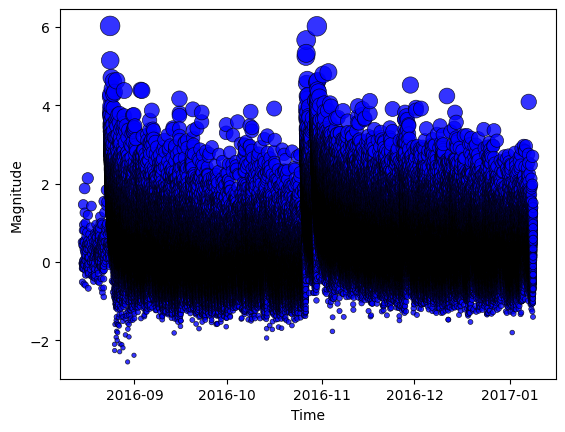

In [91]:
cat_train.plot_mags_in_time()

(-10.0, 35.0)

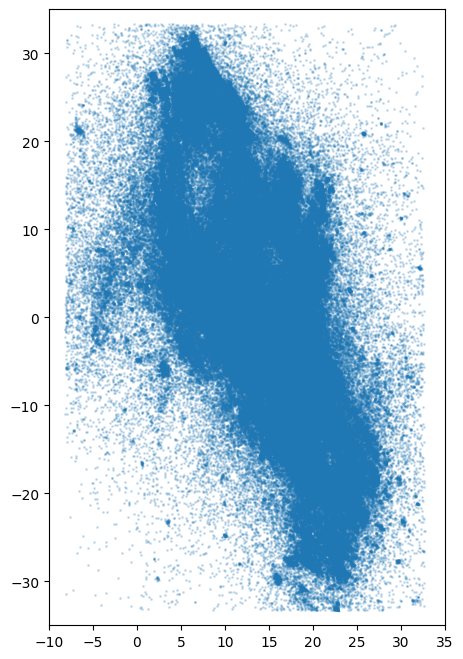

In [92]:
import numpy as np

# make ax cartopy geoaxis
import cartopy.crs as ccrs
fig = plt.figure(figsize=(12, 8))
plt.scatter(cat_train.y, cat_train.x, s=1, alpha=0.2)

#equal axis
plt.gca().set_aspect('equal', adjustable='box')

#equal axis
plt.gca().set_aspect('equal', adjustable='box')

# limit depth to 30 km
plt.ylim(-35, 35)
# limit x to 20 km
plt.xlim(-10, 35)

(-10.0, 35.0)

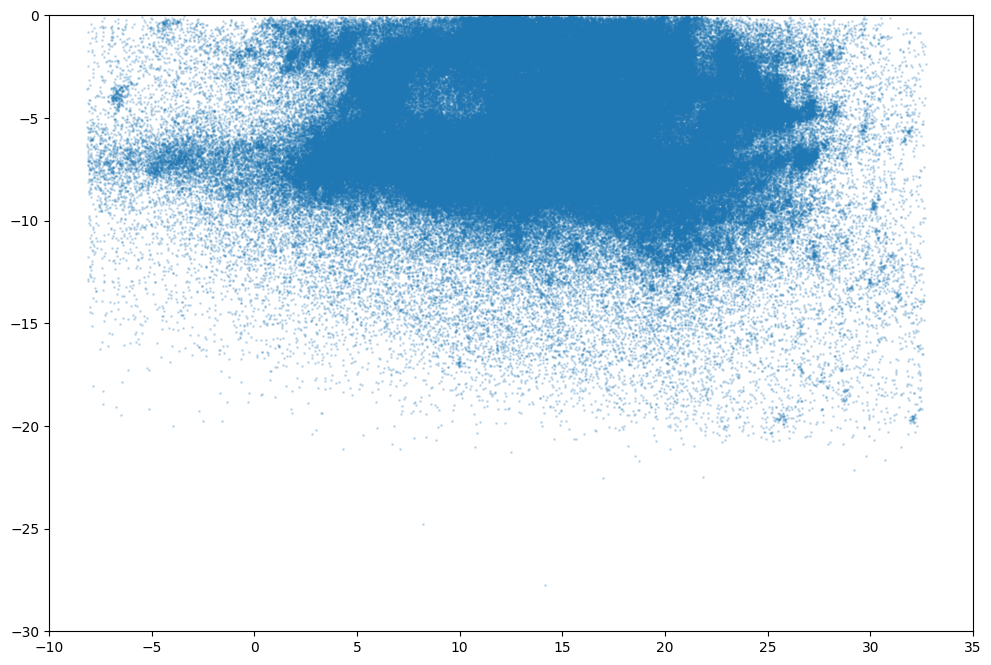

In [93]:
import numpy as np

# make ax cartopy geoaxis
import cartopy.crs as ccrs
fig = plt.figure(figsize=(12, 8))
plt.scatter(cat_train.y, cat_train.z, s=1, alpha=0.2)

#equal axis
plt.gca().set_aspect('equal', adjustable='box')

# limit depth to 30 km
plt.ylim(-30, 0)
# limit x to 20 km
plt.xlim(-10, 35)

Legend added to the plot.
Mc: 0.30


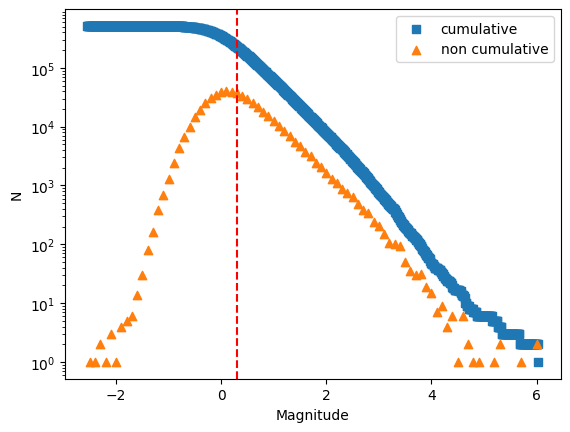

In [94]:
ax = cat_train.plot_cum_fmd()
cat_train.plot_fmd(ax = ax, fmd_bin=0.1)

cat_train.estimate_mc_maxc(fmd_bin=0.1)
plt.axvline(cat_train.mc, color='red', label='Mc', linestyle='--')
print(f'Mc: {cat_train.mc:.2f}')

In [95]:
# cutoff all events below Mc
cat_train = cat_train[cat_train.magnitude >= cat_train.mc]

# make map

In [96]:
from seismostats.utils import bin_to_precision
# sort in time
cat_train = cat_train.sort_values('time').reset_index(drop=True)

# create the magnitude differences
cat_train['mag_diff'] = bin_to_precision(cat_train['magnitude'].diff(), delta_m)
nan_idx = cat_train['mag_diff'].isna()
cat_train = cat_train[~nan_idx]

In [97]:
import itertools
# 3D grid
# coords and limits
coords = [cat_train.x.values, cat_train.y.values, cat_train.z.values]

limits = [[min(coord), max(coord)] for coord in coords]

# create grid for evaluation
delta = 2 # in km
x_vec = np.arange(limits[0][0], limits[0][1], delta)
y_vec = np.arange(limits[1][0], limits[1][1], delta)
z_vec = np.arange(limits[2][0], limits[2][1], delta)

grid = np.array(list(itertools.product(x_vec, y_vec, z_vec)))
grid = grid.T

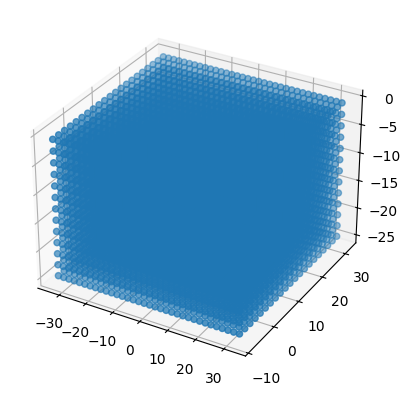

In [98]:
ax = plt.axes(projection='3d')
ax.scatter(grid[0], grid[1], grid[2])

# length scale analysis

In [99]:
volume = (limits[0][1] - limits[0][0]) * (limits[1][1] - limits[1][0]) * (limits[2][1] - limits[2][0])
n_space = 512
cell_volume = volume / n_space

cell_radius = (cell_volume/np.pi * 3/4)**(1/3)
print('radius of the cells: {:.2f} km'.format(cell_radius))


radius of the cells: 3.16 km


Legend added to the plot.
Legend added to the plot.


<Axes: xlabel='Magnitude', ylabel='N'>

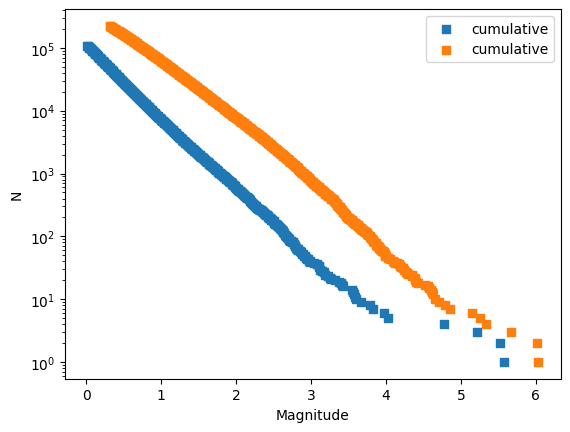

In [100]:
from seismostats.plots import plot_cum_fmd
idx = cat_train.mag_diff > 0
ax = plot_cum_fmd(cat_train.mag_diff[idx])
plot_cum_fmd(cat_train.magnitude, ax=ax)

In [101]:
from functions.space_map import mac_space
from seismostats.analysis import ClassicBValueEstimator, estimate_mc_maxc

def estimate_mc(magnitudes):
    mc, _ = estimate_mc_maxc(magnitudes, fmd_bin=fmd_bin,
                             correction_factor=correction_factor)
    return mc


warnings.filterwarnings('ignore')
idx = cat_train.mag_diff > dmc - delta_m/2
b_average_1, b_std_1, mac_spatial_1, mu_mac_spatial_1, std_mac_spatial_1 = mac_space(
    coords = [chord[idx] for chord in coords],
    mags = cat_train.mag_diff[idx],
    delta_m = cat_train.delta_m,
    times = cat_train.time[idx],
    limits = limits,
    n_space=n_space,
    n_realizations=100,
    eval_coords= grid,
    min_num=50,
    method = ClassicBValueEstimator,
    mc = dmc,
    mc_method=estimate_mc,
    transform=True,
    voronoi_method='random',
    min_count=50,
    #dmc=dmc,
)

warnings.filterwarnings('default')

Text(0, 0.5, 'North (km)')

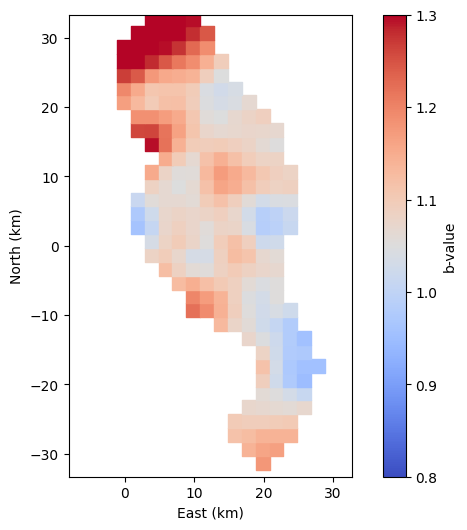

In [74]:
fig, ax = plt.subplots(figsize=(8, 6))

# choose depth slice
depth_slice = 0
mask = (grid[2] >= depth_slice - delta) & (grid[2] < depth_slice + delta)

sc =ax.scatter(grid[1, mask], grid[0, mask], c=b_average_1[mask], cmap='coolwarm', vmin=0.8, vmax=1.3, marker='s', s=100)
# colorbar
plt.colorbar(sc, ax=ax, label="b-value")
# limits
plt.ylim(limits[0][0], limits[0][1])
plt.xlim(limits[1][0], limits[1][1])

ax.set_aspect('equal', adjustable='box')
# axis labels
ax.set_xlabel('East (km)')
ax.set_ylabel('North (km)')

Text(0, 0.5, 'Depth (km)')

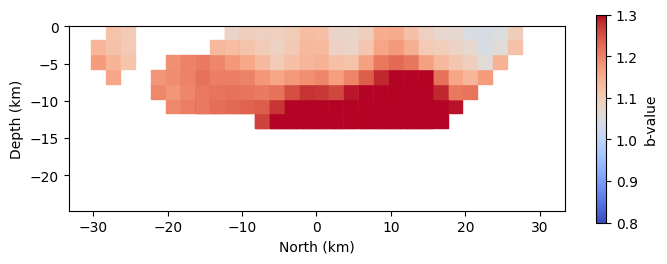

In [75]:
fig, ax = plt.subplots(figsize=(8, 6))

# choose depth slice
y_slice = 15
mask = (grid[1] >= y_slice - delta) & (grid[1] < y_slice + delta)

sc =ax.scatter(grid[0, mask], grid[2, mask], c=b_average_1[mask], cmap='coolwarm', vmin=0.8, vmax=1.3, marker='s', s=100)
# colorbar
plt.colorbar(sc, ax=ax, label="b-value", shrink=0.45)
# limits
plt.ylim(limits[2][0], limits[2][1])
plt.xlim(limits[0][0], limits[0][1])

ax.set_aspect('equal', adjustable='box')

# axis labels
ax.set_xlabel('North (km)')
ax.set_ylabel('Depth (km)')

In [76]:
from functions.space_map import mac_space
from seismostats.analysis import BPositiveBValueEstimator

warnings.filterwarnings('ignore')

b_average, b_std, mac_spatial, mu_mac_spatial, std_mac_spatial = mac_space(
    coords = coords,
    mags = cat_train.magnitude,
    delta_m = cat_train.delta_m,
    times = cat_train.time,
    limits = limits,
    n_space=n_space,
    n_realizations=100,
    eval_coords=grid,
    min_num=50,
    method = BPositiveBValueEstimator,
    mc = cat_train.mc,
    mc_method=estimate_mc,
    transform=True,
    voronoi_method='random',
    min_count=50,
    dmc=dmc,
)

warnings.filterwarnings('default')

Text(0, 0.5, 'North (km)')

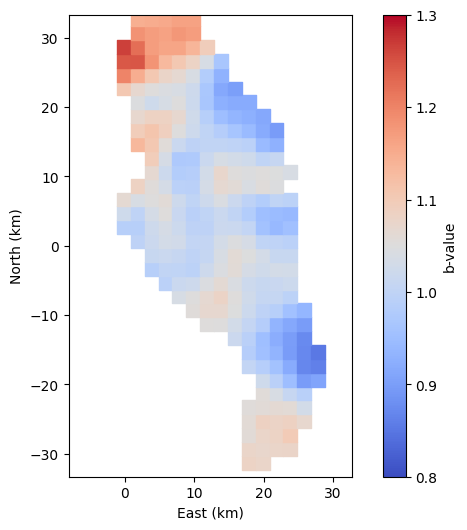

In [77]:
fig, ax = plt.subplots(figsize=(8, 6))

# choose depth slice
depth_slice = 0
mask = (grid[2] >= depth_slice - delta) & (grid[2] < depth_slice + delta)

sc =ax.scatter(grid[1, mask], grid[0, mask], c=b_average[mask], cmap='coolwarm', vmin=0.8, vmax=1.3, marker='s', s=100)
# colorbar
plt.colorbar(sc, ax=ax, label="b-value")
# limits
plt.ylim(limits[0][0], limits[0][1])
plt.xlim(limits[1][0], limits[1][1])

ax.set_aspect('equal', adjustable='box')
# axis labels
ax.set_xlabel('East (km)')
ax.set_ylabel('North (km)')

Text(0, 0.5, 'Depth (km)')

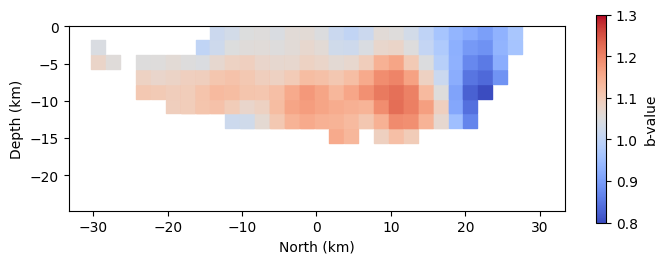

In [78]:
fig, ax = plt.subplots(figsize=(8, 6))

# choose depth slice
y_slice = 15
mask = (grid[1] >= y_slice - delta) & (grid[1] < y_slice + delta)

sc =ax.scatter(grid[0, mask], grid[2, mask], c=b_average[mask], cmap='coolwarm', vmin=0.8, vmax=1.3, marker='s', s=100)
# colorbar
plt.colorbar(sc, ax=ax, label="b-value", shrink=0.45)
# limits
plt.ylim(limits[2][0], limits[2][1])
plt.xlim(limits[0][0], limits[0][1])

ax.set_aspect('equal', adjustable='box')

# axis labels
ax.set_xlabel('North (km)')
ax.set_ylabel('Depth (km)')

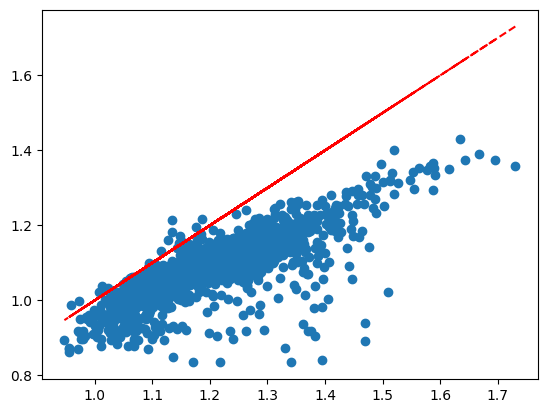

In [79]:
plt.scatter(b_average_1, b_average)
plt.plot(b_average_1, b_average_1, color='red', linestyle='--')

# MAC for different partitions

In [ ]:
from functions.space_time_separated_map import mac_spacetime
from seismostats.analysis import BPositiveBValueEstimator, ClassicBValueEstimator


# just one time for evaluation (this is for the matrix)
eval_times = [cat_train.time.max()]
eval_coords = [[coords[0][0]], [coords[1][0]], [coords[2][0]]]

n_time_list =  [64, 128, 256, 512, 1024]
n_space_list = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]

warnings.filterwarnings('ignore')
idx = cat_train.mag_diff > dmc - delta_m/2
for ii, n_time in enumerate(n_time_list):
    for jj, n_space in enumerate(n_space_list):
        if n_time * n_space < 15:
            continue
        if len(cat_train) / (n_time * n_space) < 5:
            continue
        print(f"n_time: {n_time}, n_space: {n_space}")
        (b_average,b_std,
         mac, mu_mac, std_mac,
         mac_time, mu_mac_time, std_mac_time,
         b_mac_map) = mac_spacetime(
             coords = [chord[idx] for chord in coords],
             mags = cat_train.mag_diff[idx],
             delta_m = cat_train.delta_m,
             times = cat_train.time[idx],
             limits = limits,
             n_space=n_space,
             n_time=n_time,
             space_realizations=10,
             time_realizations=10,
             eval_coords=eval_coords,
             eval_times=eval_times,
             min_num=50,
             method = ClassicBValueEstimator,
             mc = dmc,
             mc_method=estimate_mc,
             transform=True,
             voronoi_method='random',
             time_cut_method='constant_time',
             min_count=20,
             time_bar=True,
             )

        # length scale
        volume = (limits[0][1] - limits[0][0]) * (limits[1][1] - limits[1][0]) * (
            limits[2][1] - limits[2][0])
        cell_volume = volume / n_space
        s_scale = (cell_volume/np.pi * 3/4)**(1/3)
        print(s_scale)
        t_scale = (cat_train.time.max() - cat_train.time.min()) / n_time
        t_scale = t_scale / pd.Timedelta(days=1)

        # save as csv
        import csv

        filename = f"train_n_time{n_time}_n_space{n_space}.csv"
        path = "results/" + filename
        with open(path, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow([
                "s_scale",
                "t_scale",
                "mac",
                "mu_mac",
                "std_mac",
                "mac_time",
                "mu_mac_time",
                "std_mac_time"
            ])
            writer.writerow([
                s_scale,
                t_scale,
                mac,
                mu_mac,
                std_mac,
                mac_time,
                mu_mac_time,
                std_mac_time
            ])

warnings.filterwarnings('default')

n_time: 64, n_space: 1


Progress:  15%|█▍        | 16/110 [00:01<00:07, 13.07it/s]

KeyboardInterrupt: 

In [106]:
import csv
import os
results_dir = "results"
n_time_list =  [2, 4, 8, 16, 32,64, 128, 256, 512, 1024]
n_space_list = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]

macs = np.ones((len(n_time_list), len(n_space_list))) * np.nan
mu_macs = np.ones((len(n_time_list), len(n_space_list))) * np.nan
std_macs = np.ones((len(n_time_list), len(n_space_list))) * np.nan

macs_time = np.ones((len(n_time_list), len(n_space_list))) * np.nan
mu_macs_time = np.ones((len(n_time_list), len(n_space_list))) * np.nan
std_macs_time = np.ones((len(n_time_list), len(n_space_list))) * np.nan

s_scale_M = np.ones((len(n_time_list), len(n_space_list))) * np.nan
t_scale_M = np.ones((len(n_time_list), len(n_space_list))) * np.nan

for n_time in n_time_list:
    for n_space in n_space_list:
        print(f"n_time: {n_time}, n_space: {n_space}")
        filename = f"train_n_time{n_time}_n_space{n_space}.csv"
        path = os.path.join(results_dir, filename)

        try:
            with open(path, "r", newline="") as f:
                reader = csv.DictReader(f)
                row = next(reader)
                s_scale = float(row["s_scale"])
                t_scale = float(row["t_scale"])
                mac = float(row["mac"])
                mu_mac = float(row["mu_mac"])
                std_mac = float(row["std_mac"])
                mac_time = float(row["mac_time"])
                mu_mac_time = float(row["mu_mac_time"])
                #std_mac_time = float(row["std_mac_time"])
                std_mac_time = np.nan
        except:
            print(f"File not found: {path}")
            s_scale = np.nan
            t_scale = np.nan
            mac = np.nan
            mu_mac = np.nan
            std_mac = np.nan
            mac_time = np.nan
            mu_mac_time = np.nan
            std_mac_time = np.nan

        macs[n_time_list.index(n_time), n_space_list.index(n_space)] = mac
        mu_macs[n_time_list.index(n_time), n_space_list.index(n_space)] = mu_mac
        std_macs[n_time_list.index(n_time), n_space_list.index(n_space)] = std_mac
        macs_time[n_time_list.index(n_time), n_space_list.index(n_space)] = mac_time
        mu_macs_time[n_time_list.index(n_time), n_space_list.index(n_space)] = mu_mac_time
        std_macs_time[n_time_list.index(n_time), n_space_list.index(n_space)] = std_mac_time
        s_scale_M[n_time_list.index(n_time), n_space_list.index(n_space)] = s_scale
        t_scale_M[n_time_list.index(n_time), n_space_list.index(n_space)] = t_scale


n_time: 2, n_space: 1
File not found: results/train_n_time2_n_space1.csv
n_time: 2, n_space: 2
File not found: results/train_n_time2_n_space2.csv
n_time: 2, n_space: 4
File not found: results/train_n_time2_n_space4.csv
n_time: 2, n_space: 8
n_time: 2, n_space: 16
n_time: 2, n_space: 32
n_time: 2, n_space: 64
n_time: 2, n_space: 128
n_time: 2, n_space: 256
n_time: 2, n_space: 512
n_time: 2, n_space: 1024
n_time: 4, n_space: 1
File not found: results/train_n_time4_n_space1.csv
n_time: 4, n_space: 2
File not found: results/train_n_time4_n_space2.csv
n_time: 4, n_space: 4
n_time: 4, n_space: 8
n_time: 4, n_space: 16
n_time: 4, n_space: 32
n_time: 4, n_space: 64
n_time: 4, n_space: 128
n_time: 4, n_space: 256
n_time: 4, n_space: 512
n_time: 4, n_space: 1024
n_time: 8, n_space: 1
File not found: results/train_n_time8_n_space1.csv
n_time: 8, n_space: 2
n_time: 8, n_space: 4
n_time: 8, n_space: 8
n_time: 8, n_space: 16
n_time: 8, n_space: 32
n_time: 8, n_space: 64
n_time: 8, n_space: 128
n_tim

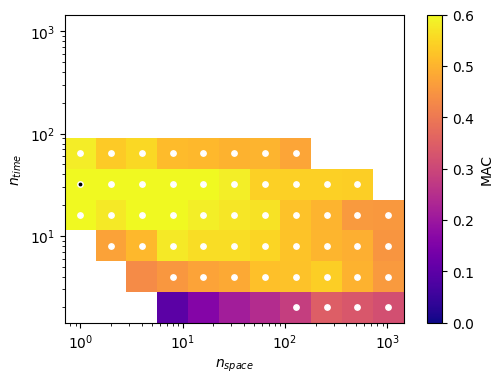

In [107]:
n_space_list = np.array(n_space_list)
n_time_list = np.array(n_time_list)

# make two subplots
fig, ax = plt.subplots(figsize=(6, 4))

def log_edges(c):
    r = np.sqrt(c[1:] / c[:-1])
    return np.concatenate(([c[0]/r[0]], c[:-1]*r, [c[-1]*r[-1]]))

Xedges, Yedges = np.meshgrid(log_edges(n_space_list), log_edges(n_time_list))

# plot MAC
im = ax.pcolormesh(Xedges, Yedges, macs, cmap='plasma', shading='auto', vmin=0, vmax=0.6)
ax.set_xlabel('$n_{space}$')
ax.set_ylabel('$n_{time}$')
ax.set_aspect('equal', adjustable='box')
# plot where significant
scaled_mac = (macs - mu_macs) / std_macs
significant = scaled_mac > 1.96

# significant points
i_sig, j_sig = np.where(significant)
ax.scatter(n_space_list[j_sig], n_time_list[i_sig], color='white', s=15)

if i_sig.size:
    k = np.argmax(macs[i_sig, j_sig])     # index of largest significant value
    i_max, j_max = i_sig[k], j_sig[k]
    ax.scatter(n_space_list[j_max], n_time_list[i_max], color='black', s=3)
ax.set_xscale('log')
ax.set_yscale('log')

# colorbar
cbar = fig.colorbar(im, ax=ax, orientation='vertical')
cbar.set_label("MAC")


# spatial only

In [ ]:
from functions.space_map import mac_space
from seismostats.analysis import BPositiveBValueEstimator

n_space_list = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]

mac_spatial_list = np.ones(len(n_space_list)) * np.nan
mu_mac_spatial_list = np.ones(len(n_space_list)) * np.nan
std_mac_spatial_list =  np.ones(len(n_space_list)) * np.nan

# just one time for evaluation (this is for the matrix)
eval_coords = [[coords[0][0]], [coords[1][0]], [coords[2][0]]]

warnings.filterwarnings('ignore')
idx = cat_train.mag_diff > dmc - delta_m/2
for ii, n_space in enumerate(n_space_list):
    if n_space < 10:
        continue
    print(f"n_space: {n_space}")
    b_average, b_std, mac_spatial, mu_mac_spatial, std_mac_spatial = mac_space(
        coords = coords[idx],
        mags = cat_train.mag_diff[idx],
        delta_m = cat_train.delta_m,
        times = cat_train.time[idx],
        limits = limits,
        n_space=n_space,
        n_realizations=200,
        eval_coords=eval_coords,
        min_num=50,
        method = ClassicBValueEstimator,
        mc = dmc,
        transform=True,
        voronoi_method='random',
        min_count=20,
    )
    mac_spatial_list[ii] = mac_spatial
    mu_mac_spatial_list[ii] = mu_mac_spatial
    std_mac_spatial_list[ii] = std_mac_spatial

warnings.filterwarnings('default')